# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Johana Oktavia Ramadhani
- **Email:** 111202315024@mhs.dinus.ac.id
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan kontribusi pengguna Casual vs Registered di setiap musim? Di musim manakah pengguna Casual paling banyak memberikan kontribusi terhadap total penyewaan?
- Pada jam berapa saja puncak penyewaan sepeda terjadi pada hari kerja (working day) dibandingkan hari libur (weekend), dan bagaimana strategi distribusi armada yang sebaiknya diterapkan?

## Import Semua Packages/Library yang Digunakan

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

### Gathering Data

In [13]:
dday = pd.read_csv("data/day.csv")
dday.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
dhour = pd.read_csv("data/hour.csv")
dhour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day terdiri dari 16 kolom yang memberikan ringkasan harian, sangat berguna untuk menganalisis tren musiman dan perbandingan antar tipe pengguna (Casual vs Registered).
- Dataset hour memiliki kolom tambahan hr (jam), yang krusial untuk menganalisis pola fluktuasi penyewaan sepeda pada jam-jam sibuk di hari kerja maupun hari libur.
- Data numerik seperti temp, atemp, hum, dan windspeed terlihat sudah dalam bentuk yang dinormalisasi (skala 0-1)

### Assessing Data

In [15]:
dday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [16]:
dday.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [17]:
dday.duplicated().sum()

np.int64(0)

In [18]:
dday.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [19]:
dhour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [20]:
dhour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [21]:
dhour.duplicated().sum()

np.int64(0)

In [22]:
dhour.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:**
- Tidak ada missing values atau data duplikat (kualitas data sangat baik).
- Kolom dteday perlu diubah dari object ke datetime untuk analisis waktu.
- Rentang penyewaan harian sangat luas (22–8.714 sepeda), menunjukkan pengaruh kuat faktor eksternal (cuaca/musim).
- Ada perbedaan besar antara rata-rata (189) dan nilai maksimum (977) per jam, mengindikasikan adanya jam sibuk (peak hours).

### Cleaning Data

In [23]:
# Mengubah dteday menjadi datetime
dday['dteday'] = pd.to_datetime(dday['dteday'])
dhour['dteday'] = pd.to_datetime(dhour['dteday'])

In [24]:
# Mengubah angka musim menjadi label teks
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
dday['season'] = dday['season'].map(season_labels)
dhour['season'] = dhour['season'].map(season_labels)

In [25]:
# Mengubah angka weathersit menjadi label teks
weather_labels = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
dday['weathersit'] = dday['weathersit'].map(weather_labels)
dhour['weathersit'] = dhour['weathersit'].map(weather_labels)

In [26]:
dday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [27]:
dday.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [32]:
dhour.to_csv("dashboard/main_data.csv", index=False)

**Insight:**
- Kolom dteday kini bertipe datetime, memungkinkan analisis tren waktu yang akurat.
- Mengubah angka menjadi teks (seperti 'Spring', 'Clear') memudahkan data untuk dibaca manusia dan mempercepat interpretasi saat pembuatan grafik.
- Dataset sudah konsisten dan siap digunakan

## Exploratory Data Analysis (EDA)

### Explore ...

In [28]:
#pola penyewaan per jam by hari kerja
dday.groupby(by="season").agg({
    "casual": ["mean", "sum"],
    "registered": ["mean", "sum"],
    "cnt": ["mean", "sum"]
})

casual           registered                  cnt         
               mean     sum         mean     sum         mean      sum
season                                                                
Fall    1202.611702  226091  4441.691489  835038  5644.303191  1061129
Spring   334.928177   60622  2269.204420  410726  2604.132597   471348
Summer  1106.097826  203522  3886.233696  715067  4992.331522   918589
Winter   729.112360  129782  3999.050562  711831  4728.162921   841613

**Insight:**
- Pengguna Registered adalah penyumbang utama di semua musim, dengan total tertinggi pada musim gugur (Fall).
- Musim gugur (Fall) merupakan musim dengan rata-rata penyewaan tertinggi ($5.644$ per hari), disusul oleh musim panas (Summer).
- Pengguna Casual paling aktif di musim panas dan musim gugur, namun jumlahnya anjlok drastis di musim semi (Spring).
- Musim semi (Spring) mencatat performa terendah dengan rata-rata hanya $2.604$ penyewaan per hari, kurang dari separuh performa musim gugur.

In [29]:
# Avg penyewaan per jam berdasarkan hari kerja
dhour.groupby(by=["workingday", "hr"])["cnt"].mean().unstack()

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
workingday,,,,,,,,,,,,,,,,,,,,,
0,90.80000,69.508696,53.171053,25.775330,8.264317,8.689189,18.742358,43.406926,105.653680,171.623377,...,364.645022,358.813853,352.727273,323.549784,281.056522,231.673913,174.739130,142.060870,116.060870,85.930435
1,36.78629,16.552632,8.683778,4.942553,5.429787,24.913131,102.500000,290.612903,477.006048,241.518145,...,183.572289,201.331325,293.122244,525.290581,492.226908,348.401606,249.718876,186.287149,138.389558,88.708835


**Insight:**
- Pola dua puncak (08:00 & 17:00), menunjukkan penggunaan untuk komuter (kerja/sekolah).
- Pola kurva lonceng, puncak di tengah hari (12:00–15:00) untuk rekreasi.
- Penyewaan terendah pada jam 00:00–04:00 di semua hari.
- Stok sepeda harus siap di area residensial pada pagi hari kerja dan area publik pada siang hari libur.

## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana perbandingan kontribusi pengguna Casual vs Registered di setiap musim? Di musim manakah pengguna Casual paling banyak memberikan kontribusi terhadap total penyewaan?

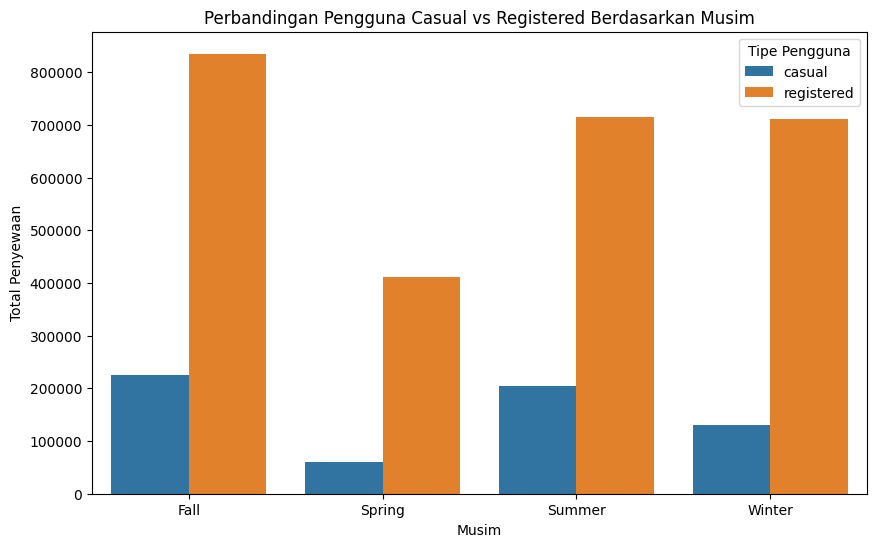

In [30]:
seasonal_usage = dday.groupby('season')[['casual', 'registered']].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    x='season',
    y='value',
    hue='variable',
    data=pd.melt(seasonal_usage, id_vars=['season']),
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Perbandingan Pengguna Casual vs Registered Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Total Penyewaan')
plt.legend(title='Tipe Pengguna')
plt.show()

### Pertanyaan 2: Pada jam berapa saja puncak penyewaan sepeda terjadi pada hari kerja (working day) dibandingkan hari libur (weekend), dan bagaimana strategi distribusi armada yang sebaiknya diterapkan?

**Insight:**
- Pengguna terdaftar (Registered) merupakan tulang punggung bisnis dengan kontribusi lebih dari 75% di semua musim.
- Pengguna Casual memberikan kontribusi tertinggi pada musim Fall (Gugur) dan Summer (Panas). Ini menunjukkan bahwa pengguna non-rutin sangat dipengaruhi oleh cuaca yang mendukung aktivitas luar ruangan.
- Musim Fall adalah periode paling menguntungkan bagi kedua tipe pengguna, sementara musim Spring mencatat performa terendah, kemungkinan karena faktor cuaca yang masih dingin/transisi.

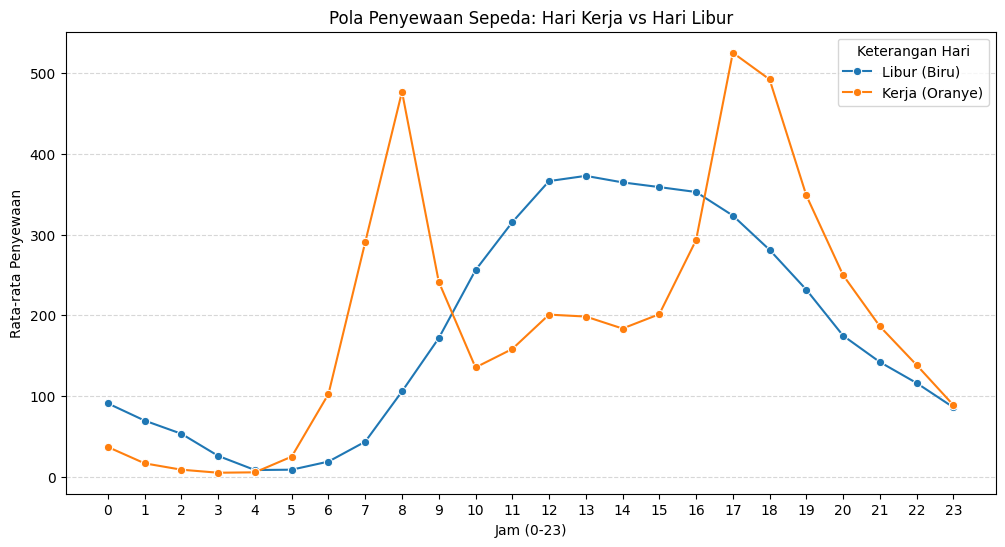

In [31]:
hourly_pattern = dhour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=hourly_pattern,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o',
    palette=['#1f77b4', '#ff7f0e'],
    hue_order=[0, 1]
)

plt.title('Pola Penyewaan Sepeda: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=['Libur (Biru)', 'Kerja (Oranye)'],
    title='Keterangan Hari'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Pola "Dua Puncak" (08:00 dan 17:00) mengonfirmasi bahwa penggunaan sepeda pada hari kerja didominasi oleh mobilitas komuter (pergi dan pulang kantor/sekolah).
- Pola "Kurva Lonceng" dengan puncak di tengah hari (12:00–15:00) menunjukkan penggunaan murni untuk rekreasi dan wisata.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclusion Pertanyaan 1:
Pengguna Registered mendominasi penyewaan di semua musim dengan kontribusi rata-rata di atas 75%. Namun, pengguna Casual menunjukkan peningkatan signifikan pada musim Fall (Gugur) dan Summer (Panas). Musim Gugur adalah waktu di mana pengguna Casual paling banyak berkontribusi, menunjukkan bahwa faktor cuaca yang nyaman sangat mendorong pengguna non-rutin untuk menyewa sepeda.

- Conclusion Pertanyaan 2:
Terdapat perbedaan pola yang kontras antara hari kerja dan hari libur. Pada hari kerja, puncak penyewaan terjadi pada pukul 08:00 dan 17:00 (pola komuter). Sedangkan pada hari libur, puncak terjadi secara stabil pada pukul 12:00 hingga 15:00 (pola rekreasi).
Strategi Distribusi: Armada harus difokuskan pada area residensial di pagi hari kerja, area perkantoran di sore hari kerja, dan area wisata/ruang publik di siang hari libur.